# Driver Monitoring System — Drowsiness Detection Module

This notebook trains the drowsiness detection module of the DMS graduation project. Together with the smoking and seatbelt modules, this is the third behavior-detection component of the system: it uses a YOLOv8 detector to recognize signs of driver drowsiness (e.g. closed eyes / yawning, depending on how the dataset classes are defined) from a camera frame.

Pipeline covered in this notebook:

1. Mounting Drive and checking the dataset folder
2. Installing dependencies
3. Loading dataset configuration and verifying the folder structure
4. Visualizing sample annotations and class distribution
5. Training YOLOv8m
6. Evaluating on the test set
7. Running inference on test images, a custom uploaded image, and a video

As with the other modules, everything runs on Colab with the dataset and results stored on Google Drive under `AI_Project/`.

## 1. Mount Drive and Locate the Dataset

The dataset for this module was prepared beforehand and lives on Google Drive under `AI_Project/Drowsiness_Final`. Mounting Drive with `force_remount=True` makes sure we get a fresh mount even if a previous session left one open, and the two `ls` commands below are just a quick manual check that the project folder and the dataset folder are actually there before doing anything else.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/AI_Project

Drowsiness_Final  Results


In [ ]:
!ls /content/drive/MyDrive/AI_Project/Drowsiness_Final

data.yaml  test  train	valid


## 2. Install Dependencies

All the libraries needed for this notebook are installed here in one place: `ultralytics` for YOLOv8, `roboflow` in case the dataset needs to be pulled or updated from there, `opencv-python-headless` for image handling without a GUI backend (Colab doesn't need one), and the usual `matplotlib` / `seaborn` / `Pillow` / `pyyaml` / `tqdm` stack for plotting, image I/O, config parsing and progress bars.

In [ ]:
!pip install -q ultralytics
!pip install -q roboflow
!pip install -q opencv-python-headless
!pip install -q matplotlib seaborn
!pip install -q Pillow pyyaml tqdm

print("All libraries installed.")

All libraries installed.


## 3. Imports and GPU Check

Standard imports for the rest of the notebook, plus a quick check that Colab actually assigned a GPU. Training a YOLOv8m model on CPU would be painfully slow, so it's worth confirming this early rather than finding out after starting a 100-epoch training run.

In [ ]:
# ==============================
# 1. Import Library
# ==============================
import os
import random
import yaml
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from tqdm import tqdm

import torch
from ultralytics import YOLO

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

GPU available: True
Tesla T4


## 4. Dataset Path

Defines the root dataset folder and the path to its `data.yaml`, and lists what's inside the dataset folder as a sanity check.

In [ ]:
# ==============================
# 2. Dataset Path
# ==============================

from pathlib import Path

DATASET_PATH = Path("/content/drive/MyDrive/AI_Project/Drowsiness_Final")

YAML_PATH = DATASET_PATH / "data.yaml"

print("Dataset path:", DATASET_PATH)
print("YAML path:", YAML_PATH)

print("\nDataset files:")
for x in DATASET_PATH.iterdir():
    print(x.name)

Dataset path: /content/drive/MyDrive/AI_Project/Drowsiness_Final
YAML path: /content/drive/MyDrive/AI_Project/Drowsiness_Final/data.yaml

Dataset files:
data.yaml
test
train
valid


## 5. Read Dataset Configuration

Loads `data.yaml` to get the class names and number of classes directly from the dataset config, instead of hardcoding them. This keeps the notebook in sync with whatever the dataset actually contains.

In [ ]:
# ==============================
# 3. Read YAML
# ==============================

with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg["names"]
NUM_CLASSES = data_cfg["nc"]

print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Number of classes: 3
Classes: {0: 'awake', 1: 'drowsy', 2: 'yawning'}


## 6. Verify Dataset Structure

For each split (train/valid/test), this counts the images and label files and flags a mismatch if the counts don't line up. A mismatch here usually means some images are missing labels (or vice versa), which is worth catching before training rather than after.

In [ ]:
# ==============================
# 4. Verify Dataset Structure
# ==============================

splits = ["train", "valid", "test"]

for split in splits:
    img_path = DATASET_PATH / split / "images"
    lbl_path = DATASET_PATH / split / "labels"

    images = list(img_path.glob("*"))
    labels = list(lbl_path.glob("*.txt"))

    print(f"\n{split}")
    print("Images:", len(images))
    print("Labels:", len(labels))

    if len(images) == len(labels):
        print("✅ OK")
    else:
        print("⚠️ Mismatch")


train
Images: 3002
Labels: 3002
✅ OK

valid
Images: 600
Labels: 600
✅ OK

test
Images: 401
Labels: 401
✅ OK


## 7. Visualize Samples

Draws bounding boxes on a random batch of training images using the class names loaded earlier, to visually confirm the annotations look correct — right class, right region of the frame — before trusting the dataset for training.

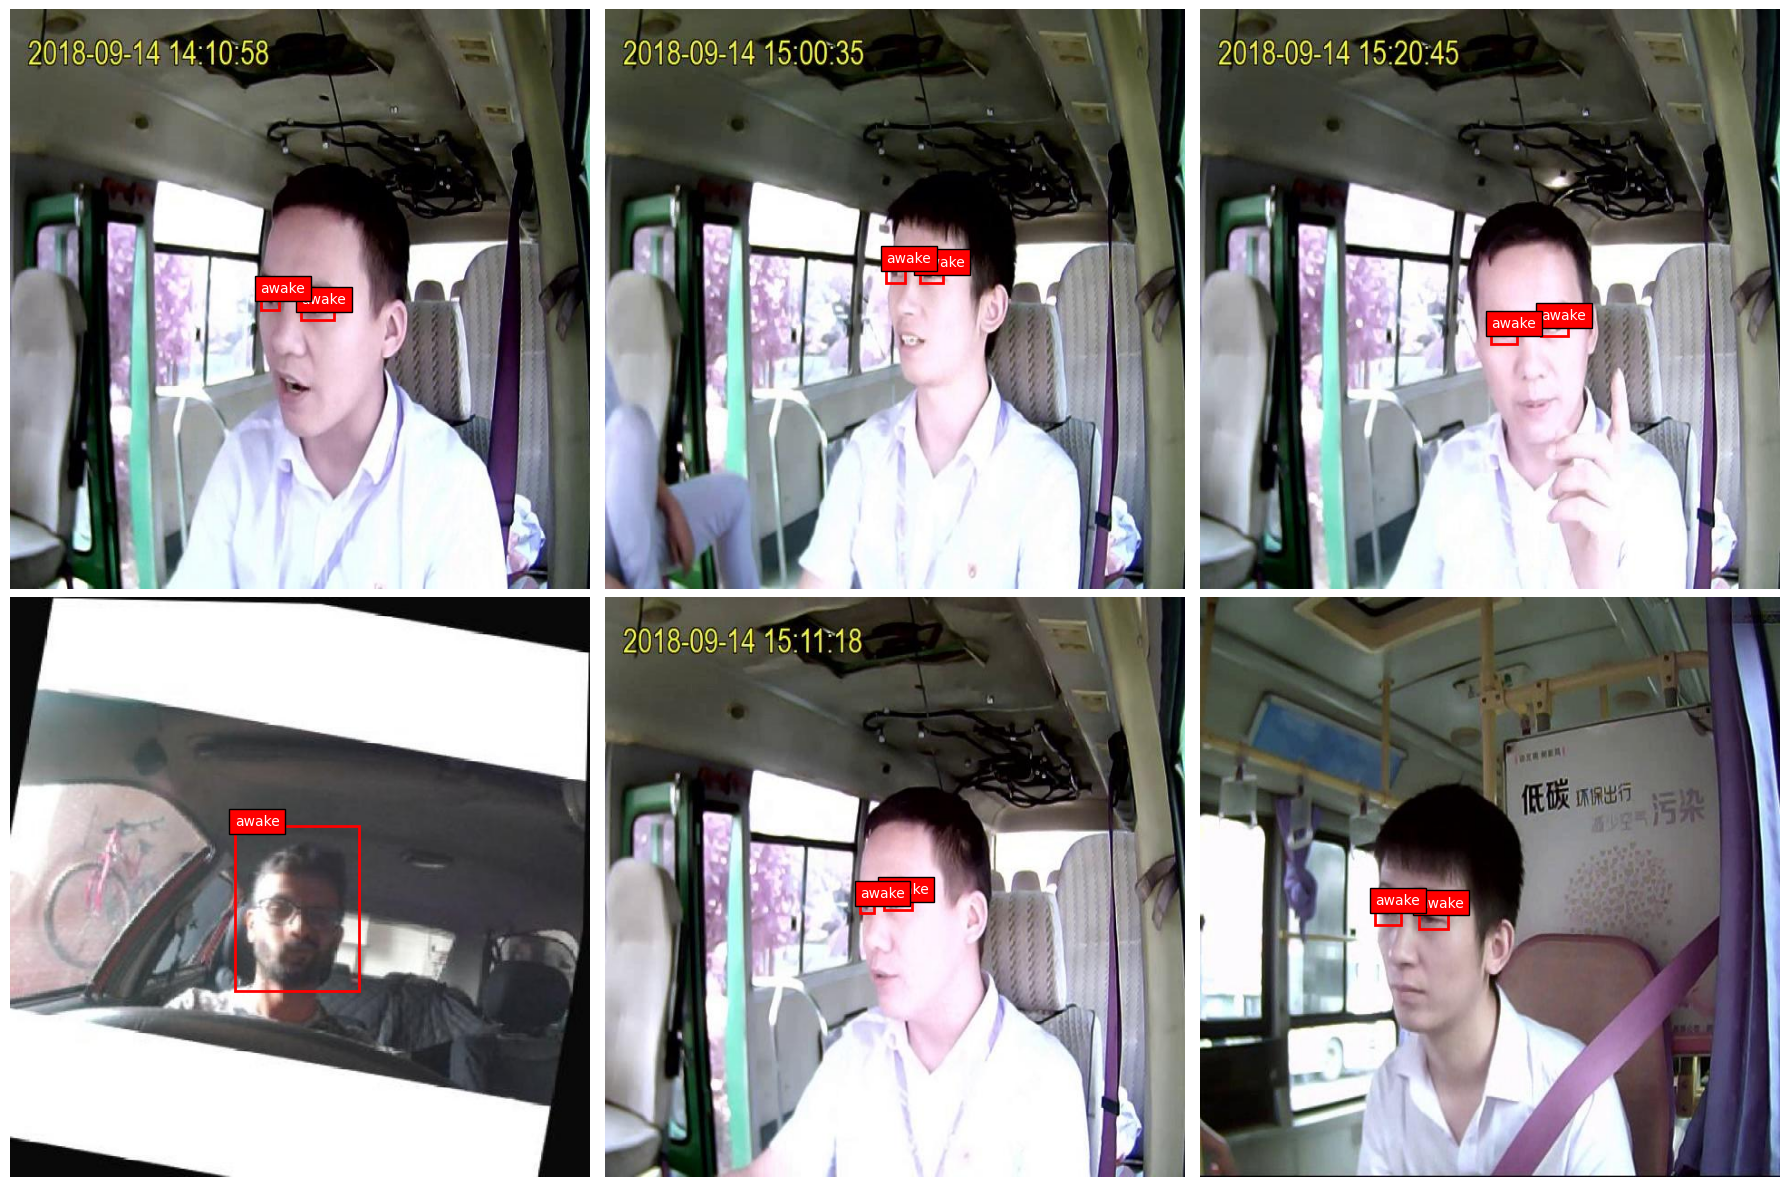

In [ ]:
# ==============================
# 5. Visualize Samples
# ==============================

import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

train_img_path = DATASET_PATH / "train" / "images"
train_lbl_path = DATASET_PATH / "train" / "labels"

images = list(train_img_path.glob("*"))

samples = random.sample(images, 6)

plt.figure(figsize=(18,12))

for i, img_file in enumerate(samples):

    img = Image.open(img_file).convert("RGB")
    w, h = img.size

    ax = plt.subplot(2,3,i+1)
    ax.imshow(img)

    label_file = train_lbl_path / f"{img_file.stem}.txt"

    if label_file.exists():

        with open(label_file) as f:
            lines = f.readlines()

        for line in lines:
            cls, x, y, bw, bh = map(float, line.split())

            x1 = (x - bw/2) * w
            y1 = (y - bh/2) * h

            rect = patches.Rectangle(
                (x1,y1),
                bw*w,
                bh*h,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1,
                CLASS_NAMES[int(cls)],
                color="white",
                fontsize=10,
                bbox=dict(facecolor="red")
            )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Class Distribution

Counts how many instances of each class appear in the train/valid/test label files. This is useful for spotting class imbalance early on (e.g. if "drowsy" examples are much rarer than "alert" ones), which can affect how the trained model performs on the minority class.

In [ ]:
# ==============================
# 6. Class Distribution
# ==============================

def count_labels(label_dir):
    counter = Counter()

    for file in label_dir.glob("*.txt"):
        with open(file) as f:
            for line in f:
                cls = line.split()[0]
                counter[int(cls)] += 1

    return counter


train_counts = count_labels(DATASET_PATH / "train" / "labels")
valid_counts = count_labels(DATASET_PATH / "valid" / "labels")
test_counts  = count_labels(DATASET_PATH / "test" / "labels")


print("Train:")
for i,name in CLASS_NAMES.items():
    print(name, ":", train_counts[i])


print("\nValid:")
for i,name in CLASS_NAMES.items():
    print(name, ":", valid_counts[i])


print("\nTest:")
for i,name in CLASS_NAMES.items():
    print(name, ":", test_counts[i])

Train:
awake : 2676
drowsy : 1975
yawning : 165

Valid:
awake : 563
drowsy : 377
yawning : 34

Test:
awake : 373
drowsy : 243
yawning : 24


## 9. Train YOLOv8

The detector is trained from the `yolov8m.pt` pretrained checkpoint for 100 epochs at 640x640, batch size 16, on GPU (`device=0`). `patience=20` enables early stopping if validation metrics stop improving.

The augmentation settings here are geared toward the kind of variation expected from an in-cabin driver camera: HSV jitter (`hsv_h/s/v`) to handle different lighting conditions, horizontal flip (`fliplr=0.5`) since drowsiness cues aren't inherently left/right specific, and both `mosaic` and a small amount of `mixup` to help the model generalize given a dataset of moderate size. Results and weights are saved under `AI_Project/Results/Drowsiness_YOLOv8m` on Drive.

In [ ]:
# ==============================
# 7. Train YOLOv8
# ==============================

model = YOLO("yolov8m.pt")

results = model.train(
    data=str(YAML_PATH),

    epochs=100,
    imgsz=640,
    batch=16,

    device=0,

    project="/content/drive/MyDrive/AI_Project/Results",
    name="Drowsiness_YOLOv8m",

    patience=20,

    save=True,
    plots=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    fliplr=0.5,

    mosaic=1.0,
    mixup=0.1
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AI_Project/Drowsiness_Final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Drowsiness_YOLOv8m-3, nbs=64, nms=False, opset=None, optimize=False, opti

## 10. Evaluate on Test Set

Loads the best checkpoint from training (`best.pt`) and runs validation on the held-out test split to get the final detection metrics for this module.

In [ ]:
from ultralytics import YOLO

# تحميل أفضل موديل
model = YOLO("/content/drive/MyDrive/AI_Project/Results/Drowsiness_YOLOv8m-3/weights/best.pt")

# تقييم على Test Set
metrics = model.val(
    data="/content/drive/MyDrive/AI_Project/Drowsiness_Final/data.yaml",
    split="test"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 3.6±4.3 ms, read: 0.0±0.0 MB/s, size: 40.0 KB)
val: Scanning /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/labels... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 40.5it/s 9.9s
val: New cache created: /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.0it/s 13.1s
                   all        401        640      0.975      0.982      0.988      0.665
                 awake        242        373      0.964      0.981      0.983      0.628
                drowsy        155        243      0.979      0.966      0.985      0.618
               yawning         24         24      0.983          1      0.995       0.75
Speed: 3.0ms preproce

## 11. Run Inference on Test Images

Runs the trained model over the entire test image folder and saves the annotated predictions to disk, which will be inspected in the next cell.

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/AI_Project/Results/Drowsiness_YOLOv8m-3/weights/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images",
    conf=0.25,
    save=True
)


image 1/401 /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images/Drowsiness_2_GOPR0492_MP4-102_jpg.rf.0191202ab79e1df020ea7671be20b58e.jpg: 640x640 1 drowsy, 36.8ms
image 2/401 /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images/Drowsiness_2_GOPR0492_MP4-103_jpg.rf.29c168bd4d954126e4a6c9d1302ff05d.jpg: 640x640 1 drowsy, 36.8ms
image 3/401 /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images/Drowsiness_2_GOPR0492_MP4-109_jpg.rf.1db07e144b25a6e4bb438fe52e6113f6.jpg: 640x640 1 awake, 28.0ms
image 4/401 /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images/Drowsiness_2_GOPR0492_MP4-121_jpg.rf.c96cd27aa9c2ee4d25209639562d950a.jpg: 640x640 1 awake, 27.9ms
image 5/401 /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images/Drowsiness_2_GOPR0492_MP4-123_jpg.rf.8ef270f697ca3df44470fed55b42dd73.jpg: 640x640 1 awake, 28.1ms
image 6/401 /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/images/Drowsiness_2_GOPR0492_MP4-135_jpg.rf.9acdb54237672e8

## 12. Preview a Prediction

Displays the first saved prediction from the previous step, just as a quick visual check that inference is working and the boxes look reasonable.

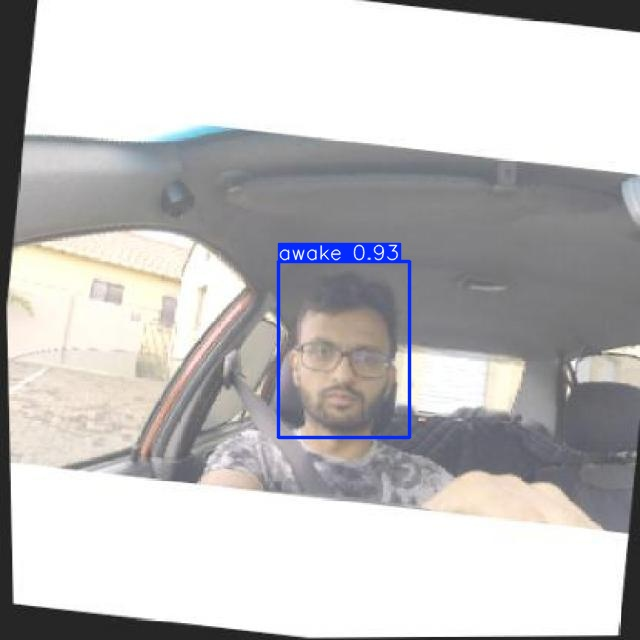

In [ ]:
from IPython.display import Image, display
import os

result_folder = "/content/runs/detect/predict"

files = os.listdir(result_folder)
display(Image(os.path.join(result_folder, files[0])))

## 13. Test on a Custom Uploaded Image

Lets you upload an arbitrary image and run the model on it. All detected boxes are printed with their confidence, and the detection with the highest confidence is reported as the "final prediction" for that image — a simple way to turn per-box detections into a single decision, similar to how this would be used in a live monitoring scenario.

Saving 2-70-_png.rf.5bd630996c0d0ae5ad5838e93cfed923.jpg to 2-70-_png.rf.5bd630996c0d0ae5ad5838e93cfed923.jpg

image 1/1 /content/2-70-_png.rf.5bd630996c0d0ae5ad5838e93cfed923.jpg: 640x640 1 awake, 1 yawning, 36.8ms
Speed: 1.7ms preprocess, 36.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-3
Detected: awake (72.25%)
Detected: yawning (31.34%)

Final Prediction: awake
Confidence: 72.25%


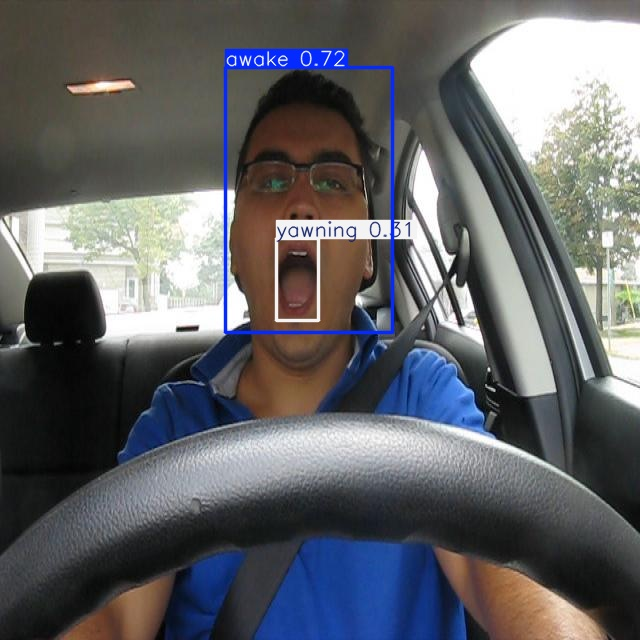

In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import os

# تحميل أفضل موديل
model = YOLO("/content/drive/MyDrive/AI_Project/Results/Drowsiness_YOLOv8m-3/weights/best.pt")

# رفع صورة
uploaded = files.upload()

# اسم الصورة
img_name = list(uploaded.keys())[0]

# Prediction
results = model.predict(
    source=img_name,
    conf=0.25,
    save=True
)

# طباعة النتائج
best_conf = 0
best_class = ""

for r in results:
    for box in r.boxes:
        conf = float(box.conf[0])
        cls = int(box.cls[0])

        print(f"Detected: {model.names[cls]} ({conf:.2%})")

        if conf > best_conf:
            best_conf = conf
            best_class = model.names[cls]

print("\n====================")
print(f"Final Prediction: {best_class}")
print(f"Confidence: {best_conf:.2%}")
print("====================")

# عرض الصورة الناتجة
save_dir = results[0].save_dir
display(Image(filename=f"{save_dir}/{img_name}"))

## 14. Validation with Plots

Re-runs validation on the test split with `plots=True`, which makes Ultralytics generate the confusion matrix, PR curves and other diagnostic plots alongside the metrics — useful for the error analysis part of the report.

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/AI_Project/Results/Drowsiness_YOLOv8m-3/weights/best.pt")

model.val(
    data="/content/drive/MyDrive/AI_Project/Drowsiness_Final/data.yaml",
    split="test",
    plots=True
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.5 ms, read: 8.8±6.6 MB/s, size: 43.1 KB)
val: Scanning /content/drive/MyDrive/AI_Project/Drowsiness_Final/test/labels.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 120.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.2it/s 11.9s
                   all        401        640      0.975      0.982      0.988      0.665
                 awake        242        373      0.964      0.981      0.983      0.628
                drowsy        155        243      0.979      0.966      0.985      0.618
               yawning         24         24      0.983          1      0.995       0.75
Speed: 2.2ms preprocess, 20.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /conte

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7e94436480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## 15. Test on a Video

Since the final system needs to work on a live camera feed rather than single frames, this cell tests the model on an uploaded video instead of a still image. Ultralytics runs the detector frame by frame and saves the annotated output video, which is located and displayed inline at the end. This is the closest test in this notebook to how the module would behave once deployed.

In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Video

# تحميل أفضل موديل
model = YOLO("/content/drive/MyDrive/AI_Project/Results/Drowsiness_YOLOv8m-3/weights/best.pt")

# رفع فيديو
uploaded = files.upload()

video_name = list(uploaded.keys())[0]

# التنبؤ على الفيديو
results = model.predict(
    source=video_name,
    conf=0.25,
    save=True
)

print("Prediction completed!")

# عرض آخر مجلد نتائج
import os

predict_folders = sorted(
    [d for d in os.listdir("/content/runs/detect") if d.startswith("predict")],
    key=lambda x: os.path.getmtime(f"/content/runs/detect/{x}")
)

latest_folder = predict_folders[-1]

output_video = os.path.join(
    "/content/runs/detect",
    latest_folder,
    video_name
)

print("Saved Video:", output_video)

# عرض الفيديو الناتج
Video(output_video, embed=True)

Saving Screen Recording 2026-06-24 183904.mp4 to Screen Recording 2026-06-24 183904.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/434) /content/Screen Recording 2026-06-24 183904.mp4: 352x640 2 awakes, 49.9ms
video 1/1 (frame 2/434) /content/Screen Recording 2026-06-24 183904.mp4: 352x640 2 awakes, 24.2ms
video 1/1 (frame 3/434) /content/Screen Recording 2026-06-24 183904.mp4: 352x640 2 awakes, 22.9ms
video 1/1 (frame 4/434) /content/Screen Recording 2026-06-24 183904.mp4: 352

## Summary and Conclusion

This notebook trained a YOLOv8m detector for driver drowsiness as the third module of the DMS project. The workflow followed the same general pattern as the other modules: verify the dataset structure and annotations visually, check class balance, train with augmentation suited to an in-cabin camera setup, and evaluate both quantitatively (metrics, confusion matrix) and qualitatively (test images, a custom image, and a video).

With this module done, all three behavior-detection components (smoking, seatbelt, drowsiness) are trained separately. The remaining work for the full DMS system is integrating the three models into a single pipeline that runs on a live camera feed and raises alerts when risky behavior is detected, and possibly re-checking class balance if the drowsy/alert split turned out uneven in the class distribution step above.